In [ ]:
import pandas as pd
import sys
import numpy as np

# Notebook uses functions from .py scripts in scripts/ folder
sys.path.append('../../scripts/signals_analysis')

from calculate import get_signals
from save import save_signals

# Calculate signals for given peaks

This notebook loads files with signal information in `.wig` format and coordinates of peaks in `.bed` format, retrieves signals for given peaks, and saves the results in `.csv` format.

Based on the experiment, you might choose:

a) Retrieving signals from DMSO and IAA samples with the same coordinates (common peaks or origin position);

b) Getting signals from a single sample;

c) Getting signals from 4 samples from different phases of the cell cycle, using the same coordinates (common peaks or origin position).

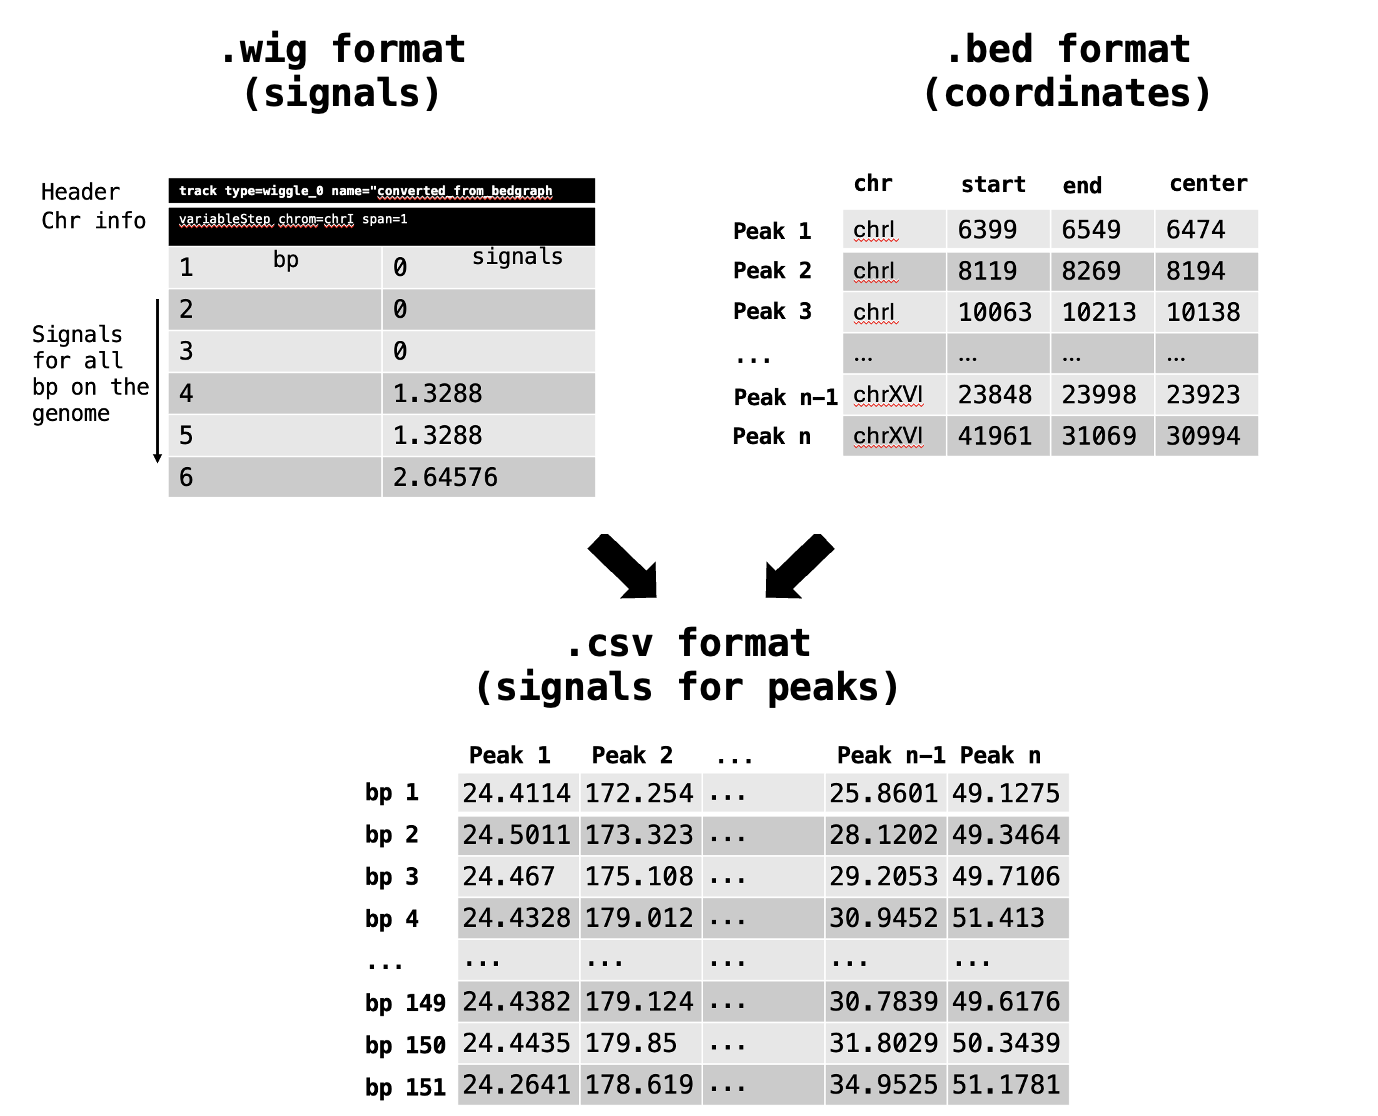

### **a) DMSO/IAA signals:** Calculate signals from .wig file from provided coordinates in .bed format

In [ ]:
output_dir = '../../results/signals/spikein_mean'
os.makedirs(output_dir, exist_ok=True) # create output directory if doesn't exist

# When comparing signals from different conditions, use same coordinates
# In case DMSOvsIAA, it's can be common peaks from compare_peaks.ipynb

# Rafal's suggestion: use only "our origins" aka common peaks for Mcm2 and Mcm4 in G1 (resources/MCM_G1.bed)
# Information how MCM_G1.bed was generated can be found in notebooks/origins_analysis
bed_path = '../../resources/MCM_G1.bed'

#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############
DMSO_wig_path = '../../../ChEC_Data_Complete/wig/spikein_mean/RDY418_as_DMSO_25_nC_spikein_mean.wig'
IAA_wig_path = '../../../ChEC_Data_Complete/wig/spikein_mean/RDY418_as_IAA_25_nC_spikein_mean.wig'

In [ ]:
DMSO_signals = get_signals(bed_path, DMSO_wig_path)
IAA_signals = get_signals(bed_path, IAA_wig_path)

# Save signals in .csv in output directory
save_signals(signals=DMSO_signals,
            in_file_path=DMSO_wig_path,
            out_dir_path=output_dir)
save_signals(signals=IAA_signals,
            in_file_path=IAA_wig_path,
            out_dir_path=output_dir)

### **b) Sample without treatment** - cpm signals

I used this for calculating cpm signals for MCM (merged Mcm2 and Mcm4) and early origins (common peaks for Sld3 G1 and MCM), when I need only one heatmap.

In [19]:
output_dir = '../../results/signals/cpm_mean/MCM_ex_Sld3_G1'

#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############
# coordinates path
bed_path = '../../results/compared_peaks/MCM_G1_RDY342_G1_nTr_nT_nC_500bp/in_MCM_G1_ex_RDY342_G1_nTr_nT_nC.bed'
# signals path
wig_path = '../../../ChEC_Data_Complete/wig/cpm_mean/RDY412_G1_nTr_nT_nC_cpm_mean.wig'

In [20]:
signals = get_signals(bed_path, wig_path)

# Save signals
save_signals(signals=signals,
            in_file_path=wig_path, # used to name new .csv file
            out_dir_path=output_dir)

Processing chromosome chrI..
Processing chromosome chrII..
Processing chromosome chrIII..
Processing chromosome chrIV..
Processing chromosome chrIX..
Processing chromosome chrV..
Processing chromosome chrVI..
Processing chromosome chrVII..
Processing chromosome chrVIII..
Processing chromosome chrX..
Processing chromosome chrXI..
Processing chromosome chrXII..
Processing chromosome chrXIII..
Processing chromosome chrXIV..
Processing chromosome chrXV..
Processing chromosome chrXVI..


### **c) Signals from 4 different stages of cell cycle - asyn, G1, S, G2/M** - cpm signals

In [ ]:
output_dir = '../../results/signals/cpm_mean'

#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############

# When comparing signals from different conditions, use same coordinates
# Rafal's suggestion: use only "our origins" aka common peaks for Mcm2 and Mcm4 in G1
bed_path = '../../results/compared_peaks//RDY368_G1_nTr_nT_nC_RDY412_G1_nTr_nT_nC/in_RDY412_G1_nTr_nT_nC_RDY368_G1_nTr_nT_nC_ex.bed'

as_wig_path = '../../../ChEC_Data_Complete/wig/cpm_mean/RDY412_as_nTr_nT_nC_cpm_mean.wig'
G1_wig_path = '../../../ChEC_Data_Complete/wig/cpm_mean/RDY412_G1_nTr_nT_nC_cpm_mean.wig'
S_wig_path = '../../../ChEC_Data_Complete/wig/cpm_mean/RDY412_S_nTr_nT_nC_cpm_mean.wig'
G2_wig_path = '../../../ChEC_Data_Complete/wig/cpm_mean/RDY412_G2_nTr_nT_nC_cpm_mean.wig'

In [ ]:
as_signals = get_signals(bed_path, as_wig_path)
G1_signals = get_signals(bed_path, G1_wig_path)
S_signals = get_signals(bed_path, S_wig_path)
G2_signals = get_signals(bed_path, G2_wig_path)

# Save signals
save_signals(signals=as_signals,
            in_file_path=as_wig_path,
            out_dir_path=output_dir)

save_signals(signals=G1_signals,
            in_file_path=G1_wig_path,
            out_dir_path=output_dir)

save_signals(signals=S_signals,
            in_file_path=S_wig_path,
            out_dir_path=output_dir)

save_signals(signals=G2_signals,
            in_file_path=G2_wig_path,
            out_dir_path=output_dir)